In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("✅ Libraries imported")

✅ Libraries imported


In [12]:
df = pd.read_csv('../data/olist_merged.csv', parse_dates=['order_purchase_timestamp'])

df = df[df['order_status'] == 'delivered']

print("✅ Data loaded!")
print(f"Total orders: {df['order_id'].nunique():,}")
print(f"Total revenue: ${df['price'].sum() + df['freight_value'].sum():,.0f}")

✅ Data loaded!
Total orders: 96,478
Total revenue: $16,188,779


In [13]:
total_revenue = (df['price'].sum() + df['freight_value'].sum()) / 1_000_000
total_orders = df['order_id'].nunique()
aov = (df['price'].sum() + df['freight_value'].sum()) / total_orders
avg_rating = df['review_score'].mean()

print("\n" + "="*50)
print("KPI SUMMARY")
print("="*50)
print(f"💰 Total Revenue: ${total_revenue:.1f}M")
print(f"📦 Total Orders: {total_orders:,}")
print(f"💵 AOV: ${aov:.0f}")
print(f"⭐ Average Rating: {avg_rating:.1f}")
print("="*50)


KPI SUMMARY
💰 Total Revenue: $16.2M
📦 Total Orders: 96,478
💵 AOV: $168
⭐ Average Rating: 4.1


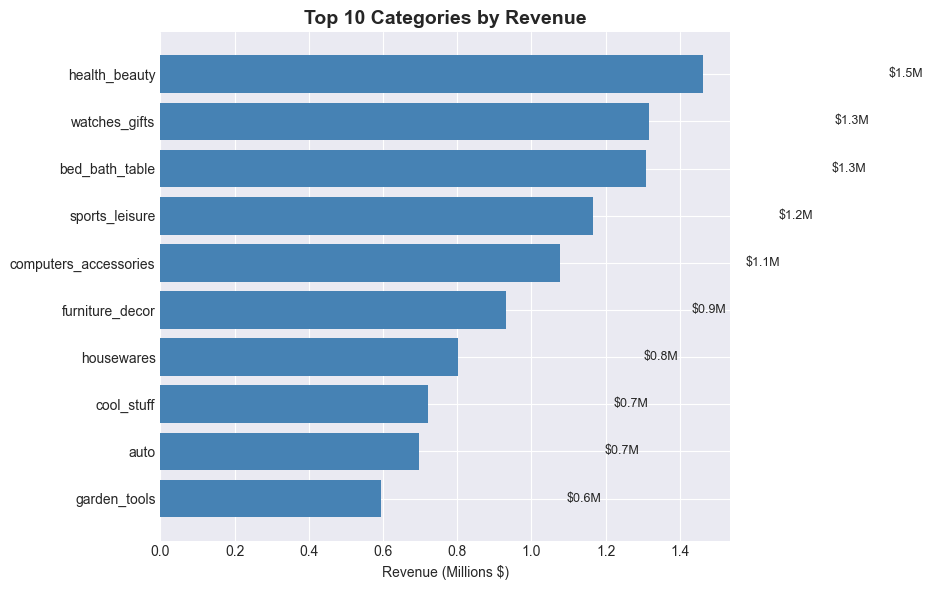

✅ Saved: ../images/top_categories_final.png


In [14]:
category_revenue = df.groupby('product_category_name_english').agg({
    'price': 'sum',
    'freight_value': 'sum'
}).reset_index()
category_revenue['total_revenue'] = category_revenue['price'] + category_revenue['freight_value']
category_revenue = category_revenue.sort_values('total_revenue', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(category_revenue['product_category_name_english'], 
               category_revenue['total_revenue'] / 1_000_000, 
               color='steelblue')
ax.set_xlabel('Revenue (Millions $)')
ax.set_title('Top 10 Categories by Revenue', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, category_revenue['total_revenue'] / 1_000_000):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
            f'${val:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/top_categories_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: ../images/top_categories_final.png")

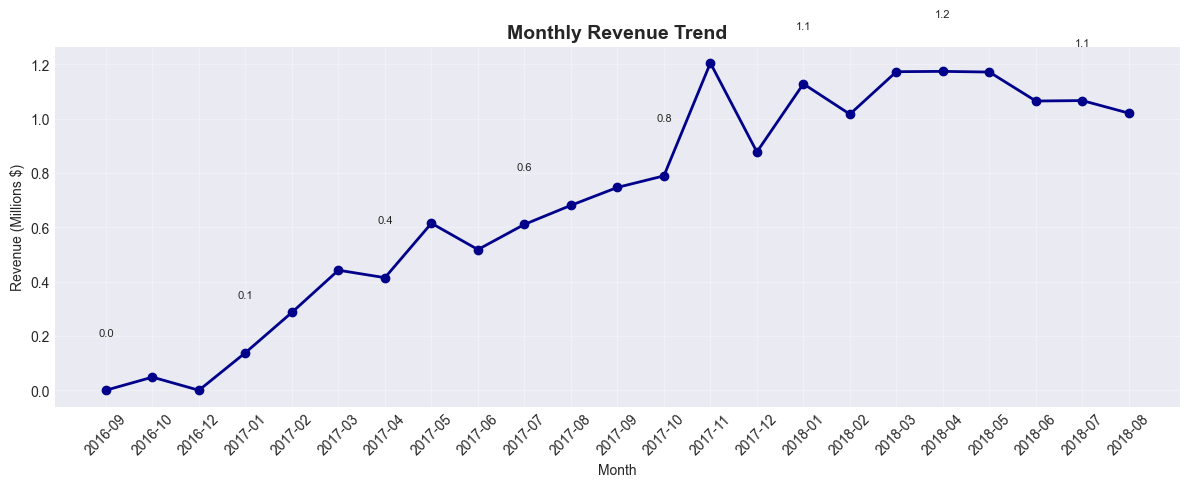

✅ Saved: ../images/revenue_trend_final.png


In [15]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = df.groupby('month').agg({
    'price': 'sum',
    'freight_value': 'sum'
}).reset_index()
monthly_revenue['total_revenue'] = monthly_revenue['price'] + monthly_revenue['freight_value']
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_revenue['month'], monthly_revenue['total_revenue'] / 1_000_000, 
        marker='o', linewidth=2, markersize=6, color='darkblue')
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (Millions $)')
plt.xticks(rotation=45)
ax.grid(True, alpha=0.3)

for i, row in monthly_revenue.iterrows():
    if i % 3 == 0:
        ax.text(row['month'], row['total_revenue']/1_000_000 + 0.2, 
                f"{row['total_revenue']/1_000_000:.1f}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../images/revenue_trend_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: ../images/revenue_trend_final.png")

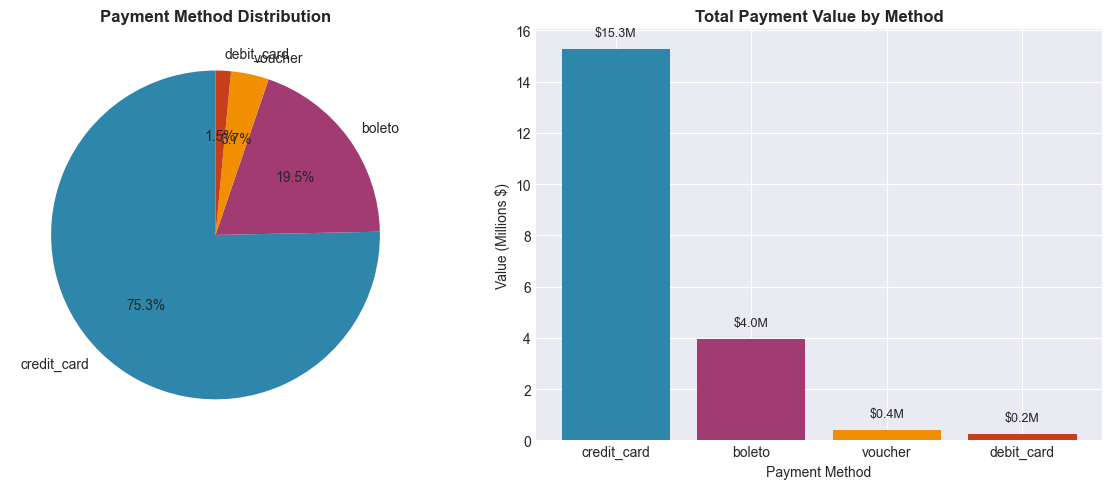

✅ Saved: ../images/payment_final.png


In [16]:
payment = df.groupby('payment_type').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()
payment = payment.sort_values('payment_value', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

ax1.pie(payment['order_id'], labels=payment['payment_type'], 
        autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Payment Method Distribution', fontsize=12, fontweight='bold')

bars = ax2.bar(payment['payment_type'], payment['payment_value'] / 1_000_000, color=colors)
ax2.set_title('Total Payment Value by Method', fontsize=12, fontweight='bold')
ax2.set_xlabel('Payment Method')
ax2.set_ylabel('Value (Millions $)')

for bar, val in zip(bars, payment['payment_value'] / 1_000_000):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'${val:.1f}M', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/payment_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: ../images/payment_final.png")

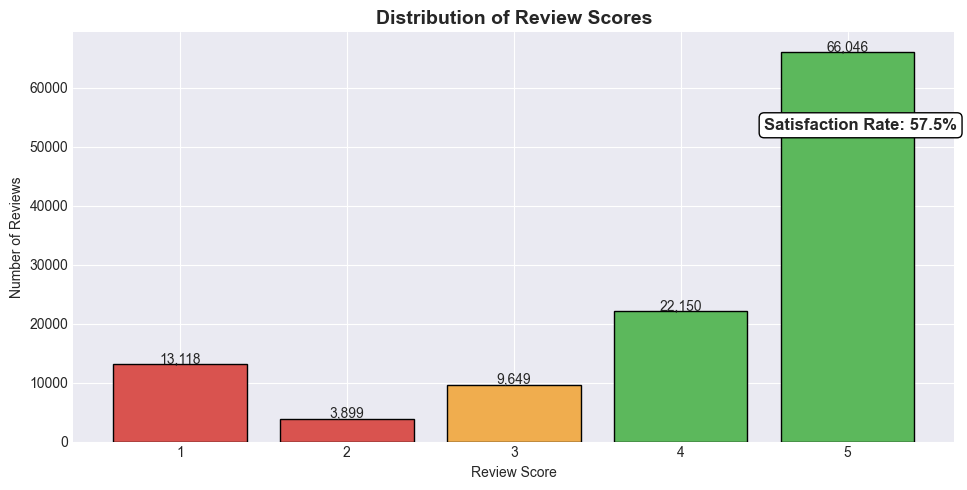

✅ Saved: ../images/review_final.png


In [11]:
review_scores = df['review_score'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#D9534F' if x <= 2 else '#F0AD4E' if x == 3 else '#5CB85C' for x in review_scores.index]
bars = ax.bar(review_scores.index, review_scores.values, color=colors, edgecolor='black')
ax.set_title('Distribution of Review Scores', fontsize=14, fontweight='bold')
ax.set_xlabel('Review Score')
ax.set_ylabel('Number of Reviews')

for bar, val in zip(bars, review_scores.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
            f'{val:,}', ha='center', fontsize=10)

satisfaction = (review_scores[4:].sum() / review_scores.sum()) * 100
ax.text(4.5, max(review_scores.values) * 0.8, 
        f'Satisfaction Rate: {satisfaction:.1f}%', 
        fontsize=12, fontweight='bold', bbox=dict(boxstyle="round", facecolor='white'))

plt.tight_layout()
plt.savefig('../images/review_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: ../images/review_final.png")

Total data for delivery analysis: 114,854 orders


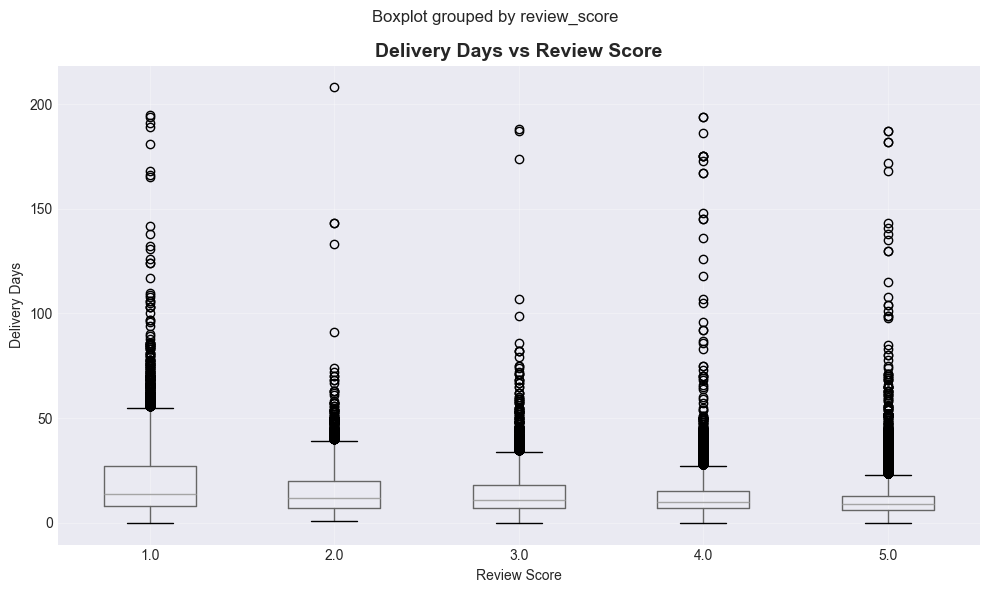

✅ Saved: ../images/delivery_vs_review_final.png


In [10]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')

valid_delivery = df[['order_purchase_timestamp', 'order_delivered_customer_date', 'review_score']].dropna()
valid_delivery['delivery_days'] = (valid_delivery['order_delivered_customer_date'] - valid_delivery['order_purchase_timestamp']).dt.days
delivery_review = valid_delivery[valid_delivery['delivery_days'] >= 0][['delivery_days', 'review_score']]

print(f"Total data for delivery analysis: {len(delivery_review):,} orders")

if len(delivery_review) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    delivery_review.boxplot(column='delivery_days', by='review_score', ax=ax)
    ax.set_title('Delivery Days vs Review Score', fontsize=14, fontweight='bold')
    ax.set_xlabel('Review Score')
    ax.set_ylabel('Delivery Days')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../images/delivery_vs_review_final.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: ../images/delivery_vs_review_final.png")
else:
    print("⚠️ No valid delivery data found for analysis")

In [9]:
print("\n" + "="*50)
print("✅ SEMUA GRAFIK TELAH DISIMPAN DI FOLDER images/")
print("="*50)
print("Files saved:")
print("   - ../images/top_categories_final.png")
print("   - ../images/revenue_trend_final.png")
print("   - ../images/payment_final.png")
print("   - ../images/review_final.png")
print("   - ../images/delivery_vs_review_final.png")
print("\n📊 All done!")


✅ SEMUA GRAFIK TELAH DISIMPAN DI FOLDER images/
Files saved:
   - ../images/top_categories_final.png
   - ../images/revenue_trend_final.png
   - ../images/payment_final.png
   - ../images/review_final.png
   - ../images/delivery_vs_review_final.png

📊 All done!
